# Визуализация графов трёх видов

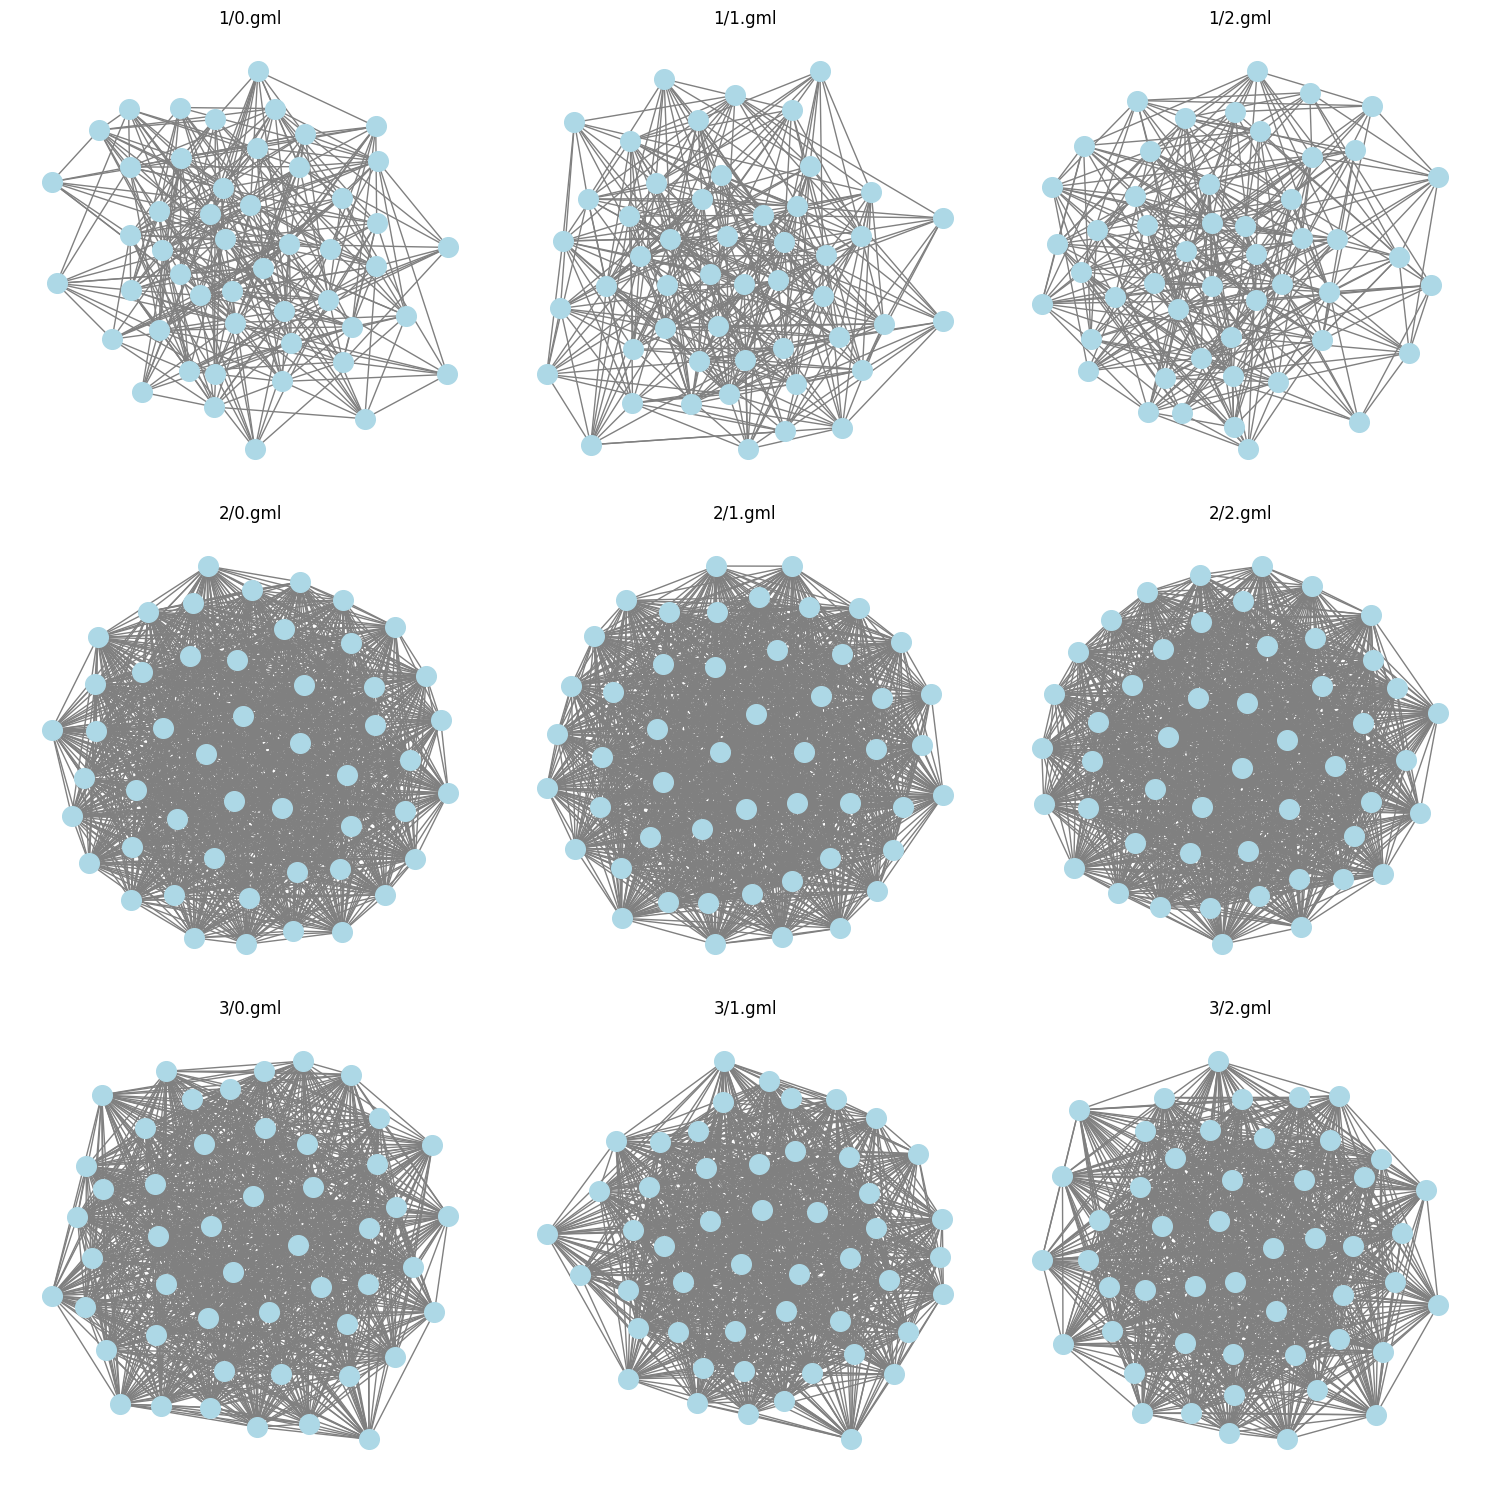

In [21]:
import networkx as nx
import matplotlib.pyplot as plt

# Список файлов для визуализации
gml_files = ['1/0.gml', '1/1.gml', '1/2.gml', '2/0.gml', '2/1.gml', '2/2.gml', '3/0.gml', '3/1.gml', '3/2.gml']

# Создаём сетку графиков
n_cols = 3
n_rows = (len(gml_files) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))

# Преобразуем axes в список
if n_rows == 1:
    axes = [axes] if n_cols == 1 else list(axes)
else:
    axes = axes.flatten()

# Визуализируем каждый файл
for i, file in enumerate(gml_files):
    G = nx.read_gml(file)
    pos = nx.spring_layout(G)
    nx.draw(G, pos, ax=axes[i], node_color='lightblue', node_size=200, edge_color='gray')
    axes[i].set_title(file)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


# Информация о датасетах

In [22]:
import os

# Информация о датасетах
datasets = ['1', '2', '3']

print("=" * 60)
print("ИНФОРМАЦИЯ О ДАТАСЕТАХ")
print("=" * 60)

for dataset in datasets:
    files = [f for f in os.listdir(dataset) if f.endswith('.gml')]
    print(f"\nДатасет {dataset}:")
    print(f"  Количество графов: {len(files)}")

    # Информация о первом графе
    first_graph = f'{dataset}/0.gml'
    if os.path.exists(first_graph):
        G = nx.read_gml(first_graph)
        print(f"\n  Первый граф (0.gml):")
        print(f"    Узлов: {G.number_of_nodes()}")
        print(f"    Рёбер: {G.number_of_edges()}")
        print(f"    Направленный: {G.is_directed()}")
        if G.number_of_nodes() > 0:
            density = nx.density(G)
            print(f"    Плотность: {density:.4f}")
        if G.number_of_nodes() > 0:
            print(f"    Средняя степень: {2*G.number_of_edges()/G.number_of_nodes():.2f}")
    print("-" * 60)


ИНФОРМАЦИЯ О ДАТАСЕТАХ

Датасет 1:
  Количество графов: 100

  Первый граф (0.gml):
    Узлов: 50
    Рёбер: 355
    Направленный: False
    Плотность: 0.2898
    Средняя степень: 14.20
------------------------------------------------------------

Датасет 2:
  Количество графов: 100

  Первый граф (0.gml):
    Узлов: 50
    Рёбер: 1110
    Направленный: False
    Плотность: 0.9061
    Средняя степень: 44.40
------------------------------------------------------------

Датасет 3:
  Количество графов: 100

  Первый граф (0.gml):
    Узлов: 50
    Рёбер: 991
    Направленный: False
    Плотность: 0.8090
    Средняя степень: 39.64
------------------------------------------------------------


# Делим все графы на train/test

In [23]:
import random

# Собираем все графы из трёх папок
folders = ['1', '2', '3']
all_paths = []
for folder in folders:
    all_paths += [f"{folder}/{name}" for name in os.listdir(folder) if name.endswith('.gml')]

# Перемешиваем и делим на train/test (80/20)
random.seed(42)
random.shuffle(all_paths)
split_idx = int(len(all_paths) * 0.8)
train_paths = all_paths[:split_idx]
test_paths = all_paths[split_idx:]

# Загружаем графы
train_graphs = [nx.read_gml(p) for p in train_paths]
test_graphs = [nx.read_gml(p) for p in test_paths]

print("Всего графов:", len(all_paths))
print("Train графов:", len(train_graphs))
print("Test графов:", len(test_graphs))
print("Пример файлов в train:", train_paths[:5])
print("Пример файлов в test:", test_paths[:5])


Всего графов: 300
Train графов: 240
Test графов: 60
Пример файлов в train: ['2/14.gml', '3/44.gml', '1/42.gml', '1/9.gml', '1/38.gml']
Пример файлов в test: ['1/97.gml', '1/31.gml', '3/28.gml', '1/62.gml', '3/25.gml']


In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.loader import DataLoader
from sklearn.metrics import accuracy_score, classification_report
import numpy as np


In [25]:
import random

# Преобразуем NetworkX графы в формат PyTorch Geometric
def nx_to_pyg(nx_graph, label):
    # Создаём маппинг от исходных узлов к числовым индексам
    nodes = list(nx_graph.nodes())
    node_to_idx = {node: idx for idx, node in enumerate(nodes)}

    # Получаем рёбра и преобразуем узлы в числовые индексы
    edges = []
    for u, v in nx_graph.edges():
        edges.append([node_to_idx[u], node_to_idx[v]])

    # Для неориентированных графов добавляем обратные рёбра
    if not nx_graph.is_directed():
        edges += [[v, u] for u, v in edges]

    if len(edges) > 0:
        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    else:
        # Если граф без рёбер, создаём пустой edge_index
        edge_index = torch.empty((2, 0), dtype=torch.long)

    # Создаём признаки узлов (используем degree как признак)
    num_nodes = nx_graph.number_of_nodes()
    degrees = [nx_graph.degree(node) for node in nodes]
    x = torch.tensor(degrees, dtype=torch.float).unsqueeze(1)

    # Нормализуем признаки
    if x.std() > 0:
        x = (x - x.mean()) / x.std()
    else:
        x = torch.zeros_like(x)  # Если все степени одинаковые

    # Создаём Data объект
    data = Data(x=x, edge_index=edge_index, y=torch.tensor([label], dtype=torch.long))
    return data

# Создаём метки классов на основе папок
def get_label_from_path(path):
    folder = path.split('/')[0]
    return int(folder) - 1  # 0, 1, 2 для папок 1, 2, 3

# Пересоздаём пути 
folders = ['1', '2', '3']
all_paths = []
for folder in folders:
    all_paths += [f"{folder}/{name}" for name in os.listdir(folder) if name.endswith('.gml')]

random.seed(42)
random.shuffle(all_paths)
split_idx = int(len(all_paths) * 0.8)
train_paths = all_paths[:split_idx]
test_paths = all_paths[split_idx:]

# Преобразуем train и test графы
train_data = []
for path in train_paths:
    nx_g = nx.read_gml(path)
    label = get_label_from_path(path)
    train_data.append(nx_to_pyg(nx_g, label))

test_data = []
for path in test_paths:
    nx_g = nx.read_gml(path)
    label = get_label_from_path(path)
    test_data.append(nx_to_pyg(nx_g, label))

print(f"Train примеров: {len(train_data)}")
print(f"Test примеров: {len(test_data)}")
print(f"Размерность признаков узлов: {train_data[0].x.shape[1]}")
print(f"Количество классов: 3")


Train примеров: 240
Test примеров: 60
Размерность признаков узлов: 1
Количество классов: 3


In [26]:

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

# GCN для классификации графов

In [27]:
class GCNGraphClassifier(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_classes):
        super(GCNGraphClassifier, self).__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.classifier = nn.Linear(hidden_dim, num_classes)

    def forward(self, x, edge_index, batch):
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = F.relu(self.conv3(x, edge_index))

        # Глобальное усреднение для получения представления графа
        x = global_mean_pool(x, batch)

        # Классификация
        x = self.classifier(x)
        return x


model = GCNGraphClassifier(input_dim=1, hidden_dim=64, num_classes=3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

print(model)


GCNGraphClassifier(
  (conv1): GCNConv(1, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (classifier): Linear(in_features=64, out_features=3, bias=True)
)


In [28]:
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()
        out = model(batch.x, batch.edge_index, batch.batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def test(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)
            out = model(batch.x, batch.edge_index, batch.batch)
            pred = out.argmax(dim=1)
            correct += (pred == batch.y).sum().item()
            total += batch.y.size(0)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    return correct / total, all_preds, all_labels

num_epochs = 50
train_losses = []
train_accs = []
test_accs = []


for epoch in range(num_epochs):
    loss = train_epoch(model, train_loader, optimizer, criterion, device)
    train_acc, _, _ = test(model, train_loader, device)
    test_acc, _, _ = test(model, test_loader, device)

    train_losses.append(loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}/{num_epochs}, Loss: {loss:.4f}, Train Acc: {train_acc:.4f}, Test Acc: {test_acc:.4f}')




Epoch 10/50, Loss: 0.7878, Train Acc: 0.6167, Test Acc: 0.7167
Epoch 20/50, Loss: 0.2759, Train Acc: 1.0000, Test Acc: 1.0000
Epoch 30/50, Loss: 0.0481, Train Acc: 1.0000, Test Acc: 1.0000
Epoch 40/50, Loss: 0.0150, Train Acc: 1.0000, Test Acc: 1.0000
Epoch 50/50, Loss: 0.0078, Train Acc: 1.0000, Test Acc: 1.0000


# Результат классификации на графах

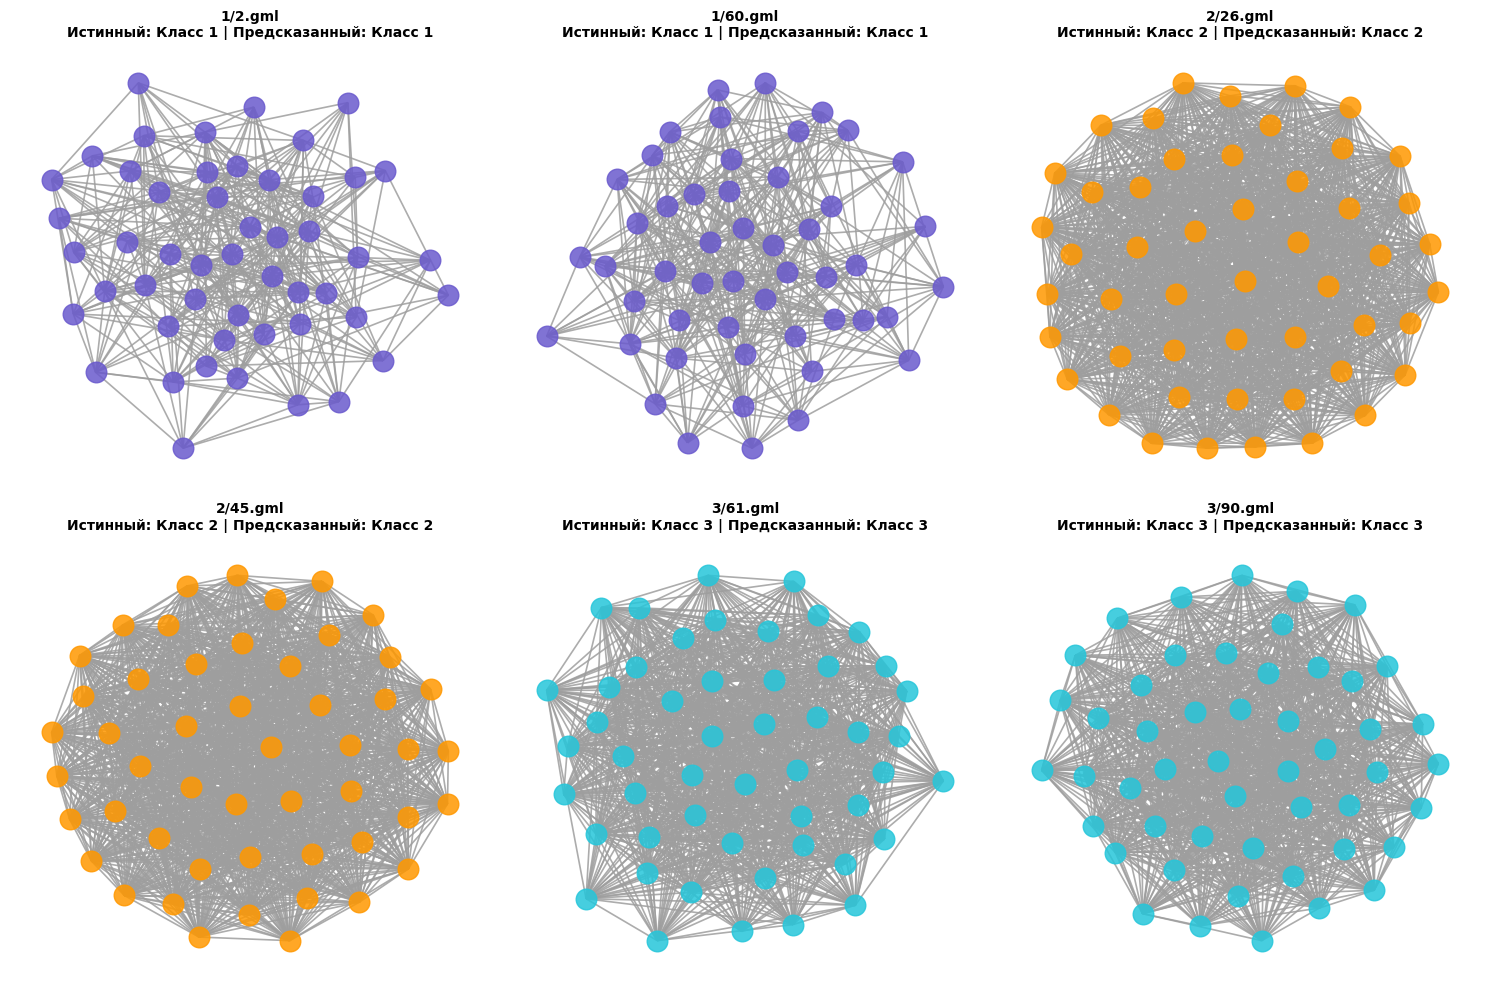

In [29]:
# Визуализация результатов классификации
import random

# Цвета для классов
class_colors = ['#6A5ACD', '#FF9800', '#26C6DA']  
class_names = ['Класс 1', 'Класс 2', 'Класс 3']

model.eval()
all_predictions = []
true_labels_list = []

with torch.no_grad():
    for data in test_data:
        data = data.to(device)
        batch = torch.zeros(data.x.size(0), dtype=torch.long).to(device)
        out = model(data.x, data.edge_index, batch)
        pred = out.argmax(dim=1).item()
        all_predictions.append(pred)
        true_labels_list.append(data.y.item())

# Берём по 2 случайных графа каждого истинного класса 
selected_graphs, selected_paths = [], []
selected_true_labels, selected_pred_labels = [], []
for class_id in range(3):
    idxs = [i for i, lbl in enumerate(true_labels_list) if lbl == class_id]
    if idxs:
        for idx in random.sample(idxs, min(2, len(idxs))):
            selected_graphs.append(nx.read_gml(test_paths[idx]))
            selected_paths.append(test_paths[idx])
            selected_true_labels.append(true_labels_list[idx])
            selected_pred_labels.append(all_predictions[idx])

n_graphs = len(selected_graphs)
if n_graphs == 0:
    print("Нет графов для визуализации.")
else:
    n_cols = 3
    n_rows = (n_graphs + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_graphs > 1 else [axes]

    for i, (G, path, true_label, pred_label) in enumerate(zip(selected_graphs, selected_paths, selected_true_labels, selected_pred_labels)):
        ax = axes[i]
        pos = nx.spring_layout(G, k=1, iterations=40)
        node_color = class_colors[pred_label]
        nx.draw(G, pos, ax=ax, node_color=node_color, node_size=220,
               edge_color='#9E9E9E', width=1.2, with_labels=False, alpha=0.85)
        title = f'{path}\nИстинный: {class_names[true_label]} | Предсказанный: {class_names[pred_label]}'
        ax.set_title(title, fontsize=10, fontweight='bold')
        ax.axis('off')

    for j in range(n_graphs, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()


# Итог

In [30]:
# Финальная оценка
test_acc, test_preds, test_labels = test(model, test_loader, device)
print(f"\nФинальная точность на тесте: {test_acc:.4f}")
print("\nОтчёт о классификации:")
print(classification_report(test_labels, test_preds, target_names=['Класс 1', 'Класс 2', 'Класс 3']))



Финальная точность на тесте: 1.0000

Отчёт о классификации:
              precision    recall  f1-score   support

     Класс 1       1.00      1.00      1.00        24
     Класс 2       1.00      1.00      1.00        22
     Класс 3       1.00      1.00      1.00        14

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60

